In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.titlesize": 13, "axes.titleweight": "bold"})
PALETTE = {"No": "#4CAF50", "Yes": "#F44336"}

DATA = "/Users/pravintakpire/datascience/KAGGLE_COMPETITION/Predict_Customer_Churn/data/"

orig  = pd.read_csv(DATA + "WA_Fn-UseC_-Telco-Customer-Churn.csv")
train = pd.read_csv(DATA + "train.csv")
test  = pd.read_csv(DATA + "test.csv")

# Fix TotalCharges (object in original — spaces for 11 missing rows)
orig["TotalCharges"] = pd.to_numeric(orig["TotalCharges"], errors="coerce")
orig["TotalCharges"].fillna(orig["TotalCharges"].median(), inplace=True)

# Binary target
orig["Churn_bin"]  = (orig["Churn"]  == "Yes").astype(int)
train["Churn_bin"] = (train["Churn"] == "Yes").astype(int)

CAT_COLS = ["gender","Partner","Dependents","PhoneService","MultipleLines",
            "InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
            "TechSupport","StreamingTV","StreamingMovies","Contract",
            "PaperlessBilling","PaymentMethod"]
NUM_COLS = ["tenure","MonthlyCharges","TotalCharges"]

print(f"Original   : {orig.shape}  | Churn rate: {orig.Churn_bin.mean():.4f}")
print(f"Train (pl) : {train.shape} | Churn rate: {train.Churn_bin.mean():.4f}")
print(f"Test  (pl) : {test.shape}")
print(f"\nChurn rate delta: {orig.Churn_bin.mean() - train.Churn_bin.mean():.4f} (orig is higher)")


Original   : (7043, 22)  | Churn rate: 0.2654
Train (pl) : (594194, 22) | Churn rate: 0.2252
Test  (pl) : (254655, 20)

Churn rate delta: 0.0402 (orig is higher)


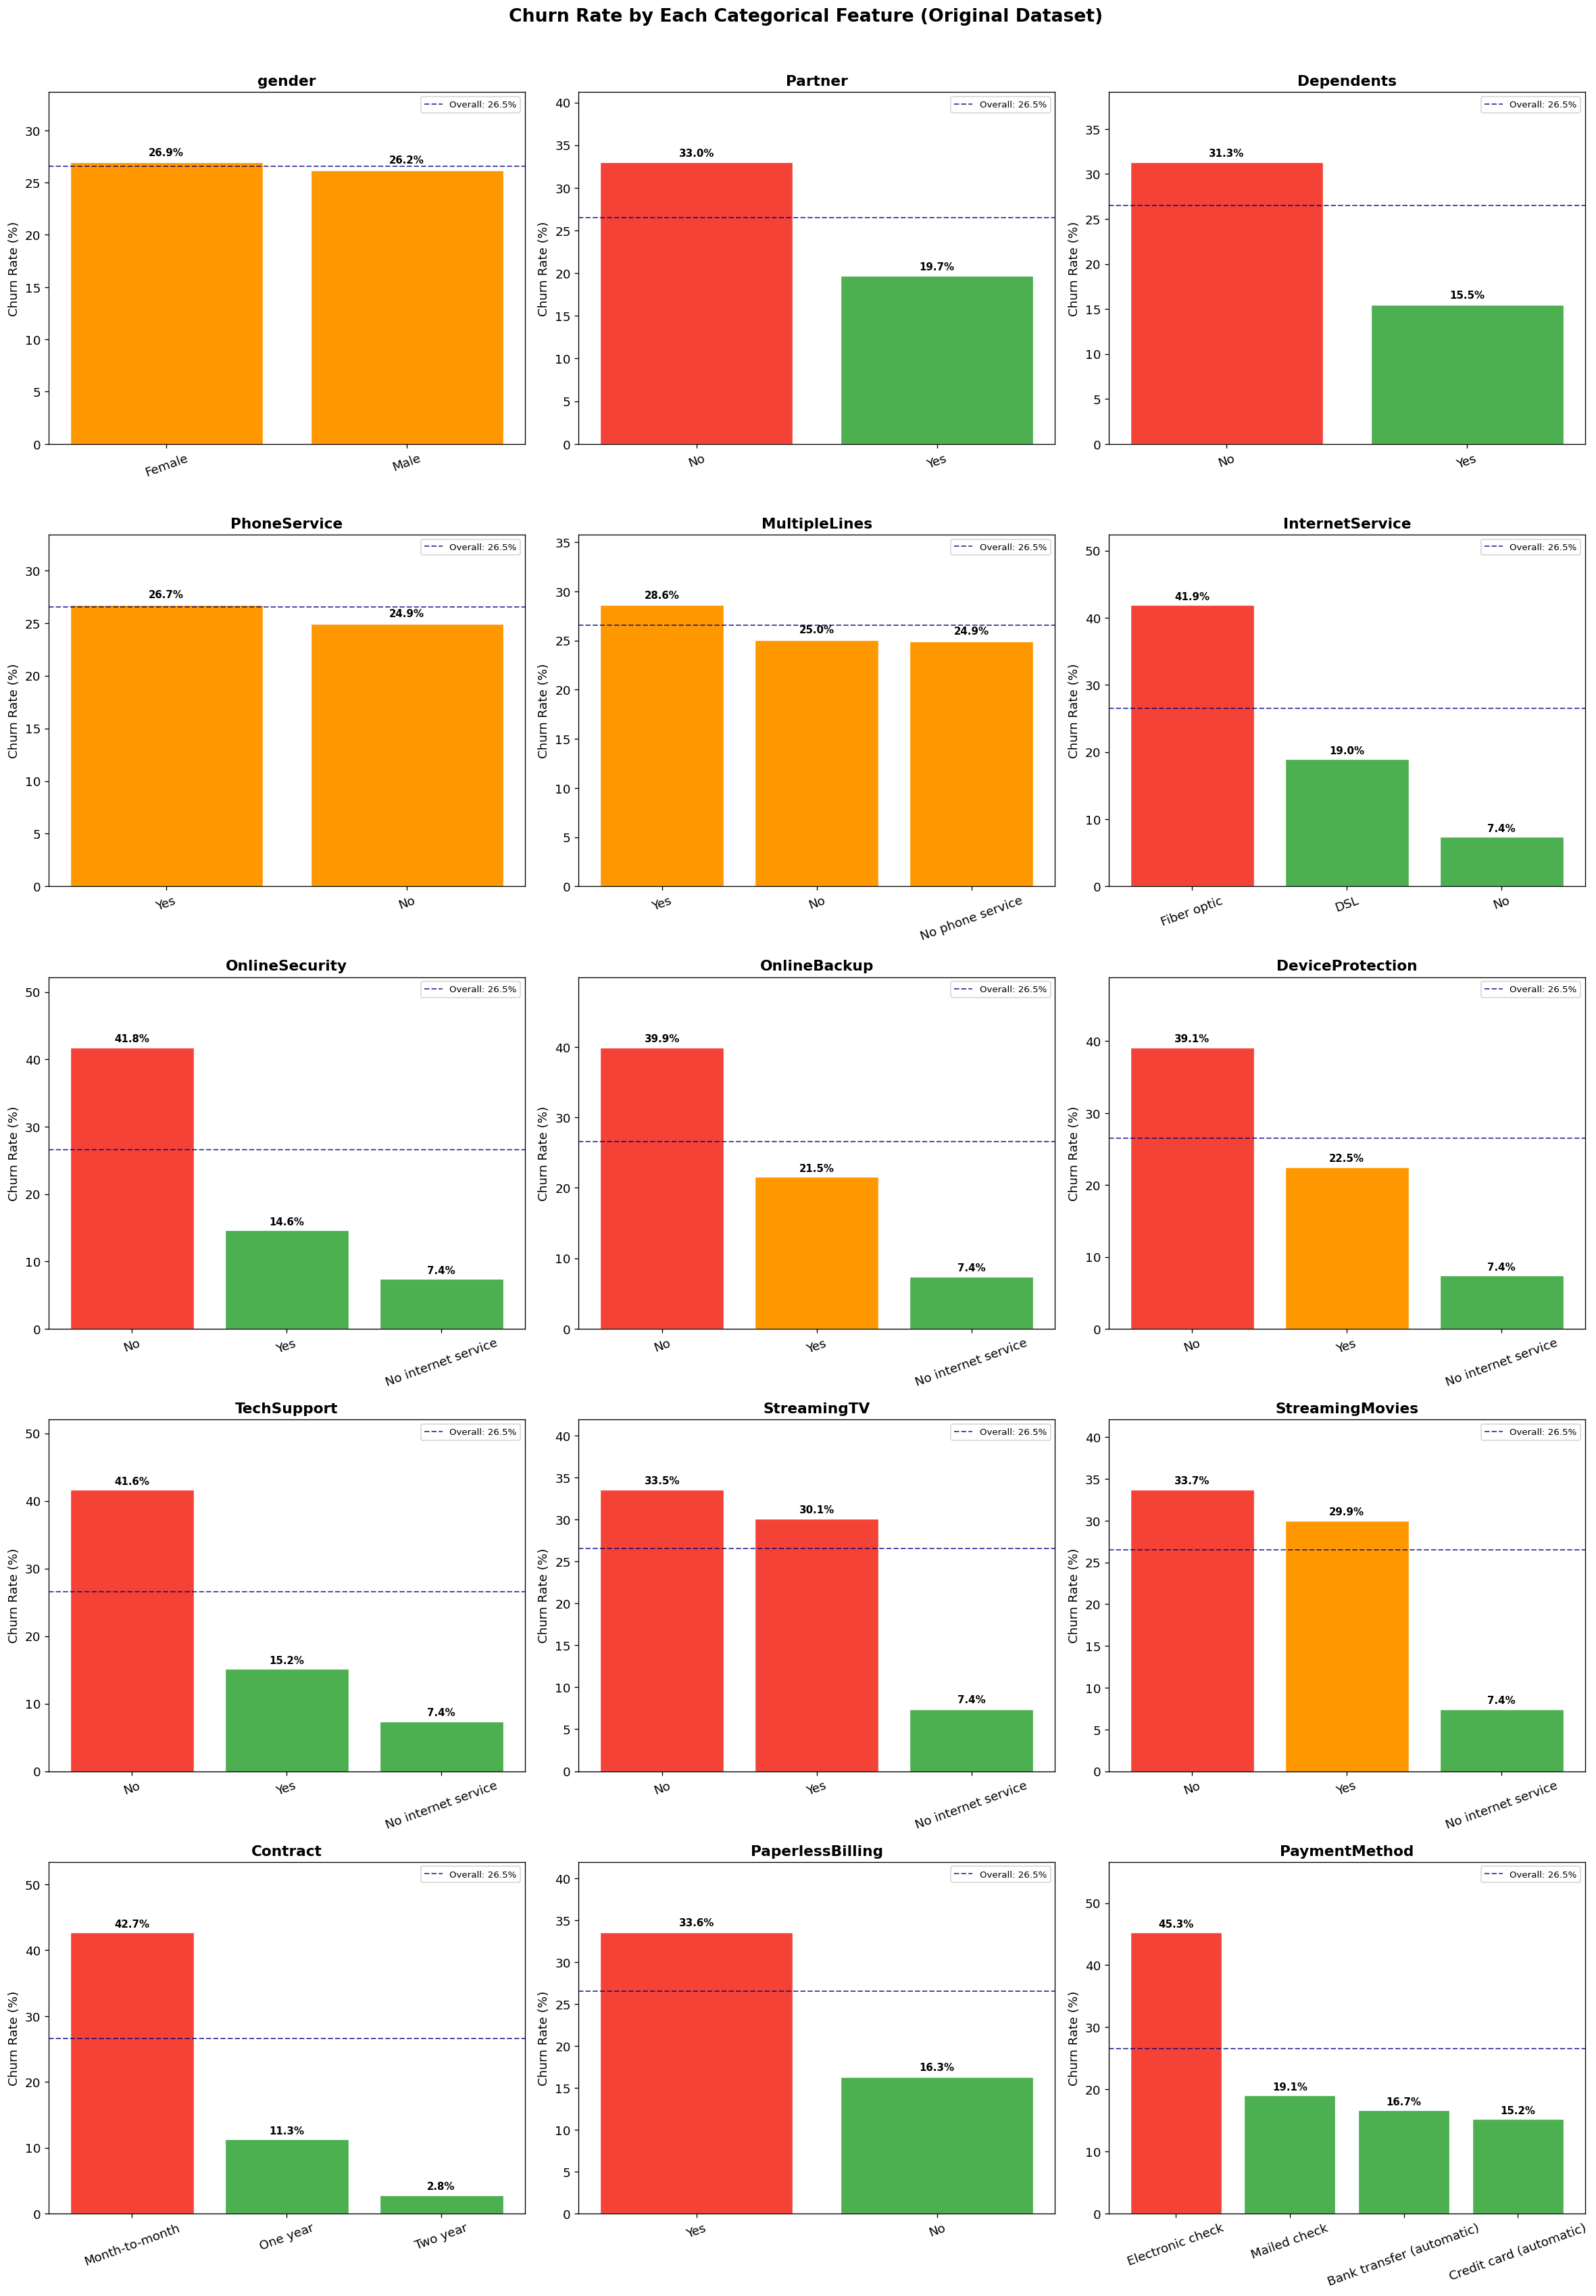

Key observations:
  gender              : max=26.9%  min=26.2%  spread=0.8pp  highest=Female
  Partner             : max=33.0%  min=19.7%  spread=13.3pp  highest=No
  Dependents          : max=31.3%  min=15.5%  spread=15.8pp  highest=No
  PhoneService        : max=26.7%  min=24.9%  spread=1.8pp  highest=Yes
  MultipleLines       : max=28.6%  min=24.9%  spread=3.7pp  highest=Yes
  InternetService     : max=41.9%  min=7.4%  spread=34.5pp  highest=Fiber optic
  OnlineSecurity      : max=41.8%  min=7.4%  spread=34.4pp  highest=No
  OnlineBackup        : max=39.9%  min=7.4%  spread=32.5pp  highest=No
  DeviceProtection    : max=39.1%  min=7.4%  spread=31.7pp  highest=No
  TechSupport         : max=41.6%  min=7.4%  spread=34.2pp  highest=No
  StreamingTV         : max=33.5%  min=7.4%  spread=26.1pp  highest=No
  StreamingMovies     : max=33.7%  min=7.4%  spread=26.3pp  highest=No
  Contract            : max=42.7%  min=2.8%  spread=39.9pp  highest=Month-to-month
  PaperlessBilling    : max=33

In [2]:
fig, axes = plt.subplots(5, 3, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    rates = orig.groupby(col)["Churn_bin"].mean().sort_values(ascending=False) * 100
    bars  = ax.bar(rates.index, rates.values,
                   color=["#F44336" if v > 30 else "#FF9800" if v > 20 else "#4CAF50"
                          for v in rates.values], edgecolor="white", linewidth=0.8)
    ax.axhline(orig.Churn_bin.mean()*100, color="navy", linestyle="--",
               linewidth=1.2, alpha=0.7, label=f"Overall: {orig.Churn_bin.mean()*100:.1f}%")
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(col)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, max(rates.values) * 1.25)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)

for j in range(len(CAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Churn Rate by Each Categorical Feature (Original Dataset)",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_churn_by_categorical.png", bbox_inches="tight", dpi=120)
plt.show()
print("Key observations:")
for col in CAT_COLS:
    rates = orig.groupby(col)["Churn_bin"].mean() * 100
    spread = rates.max() - rates.min()
    best   = rates.idxmax()
    print(f"  {col:20s}: max={rates.max():.1f}%  min={rates.min():.1f}%  "
          f"spread={spread:.1f}pp  highest={best}")


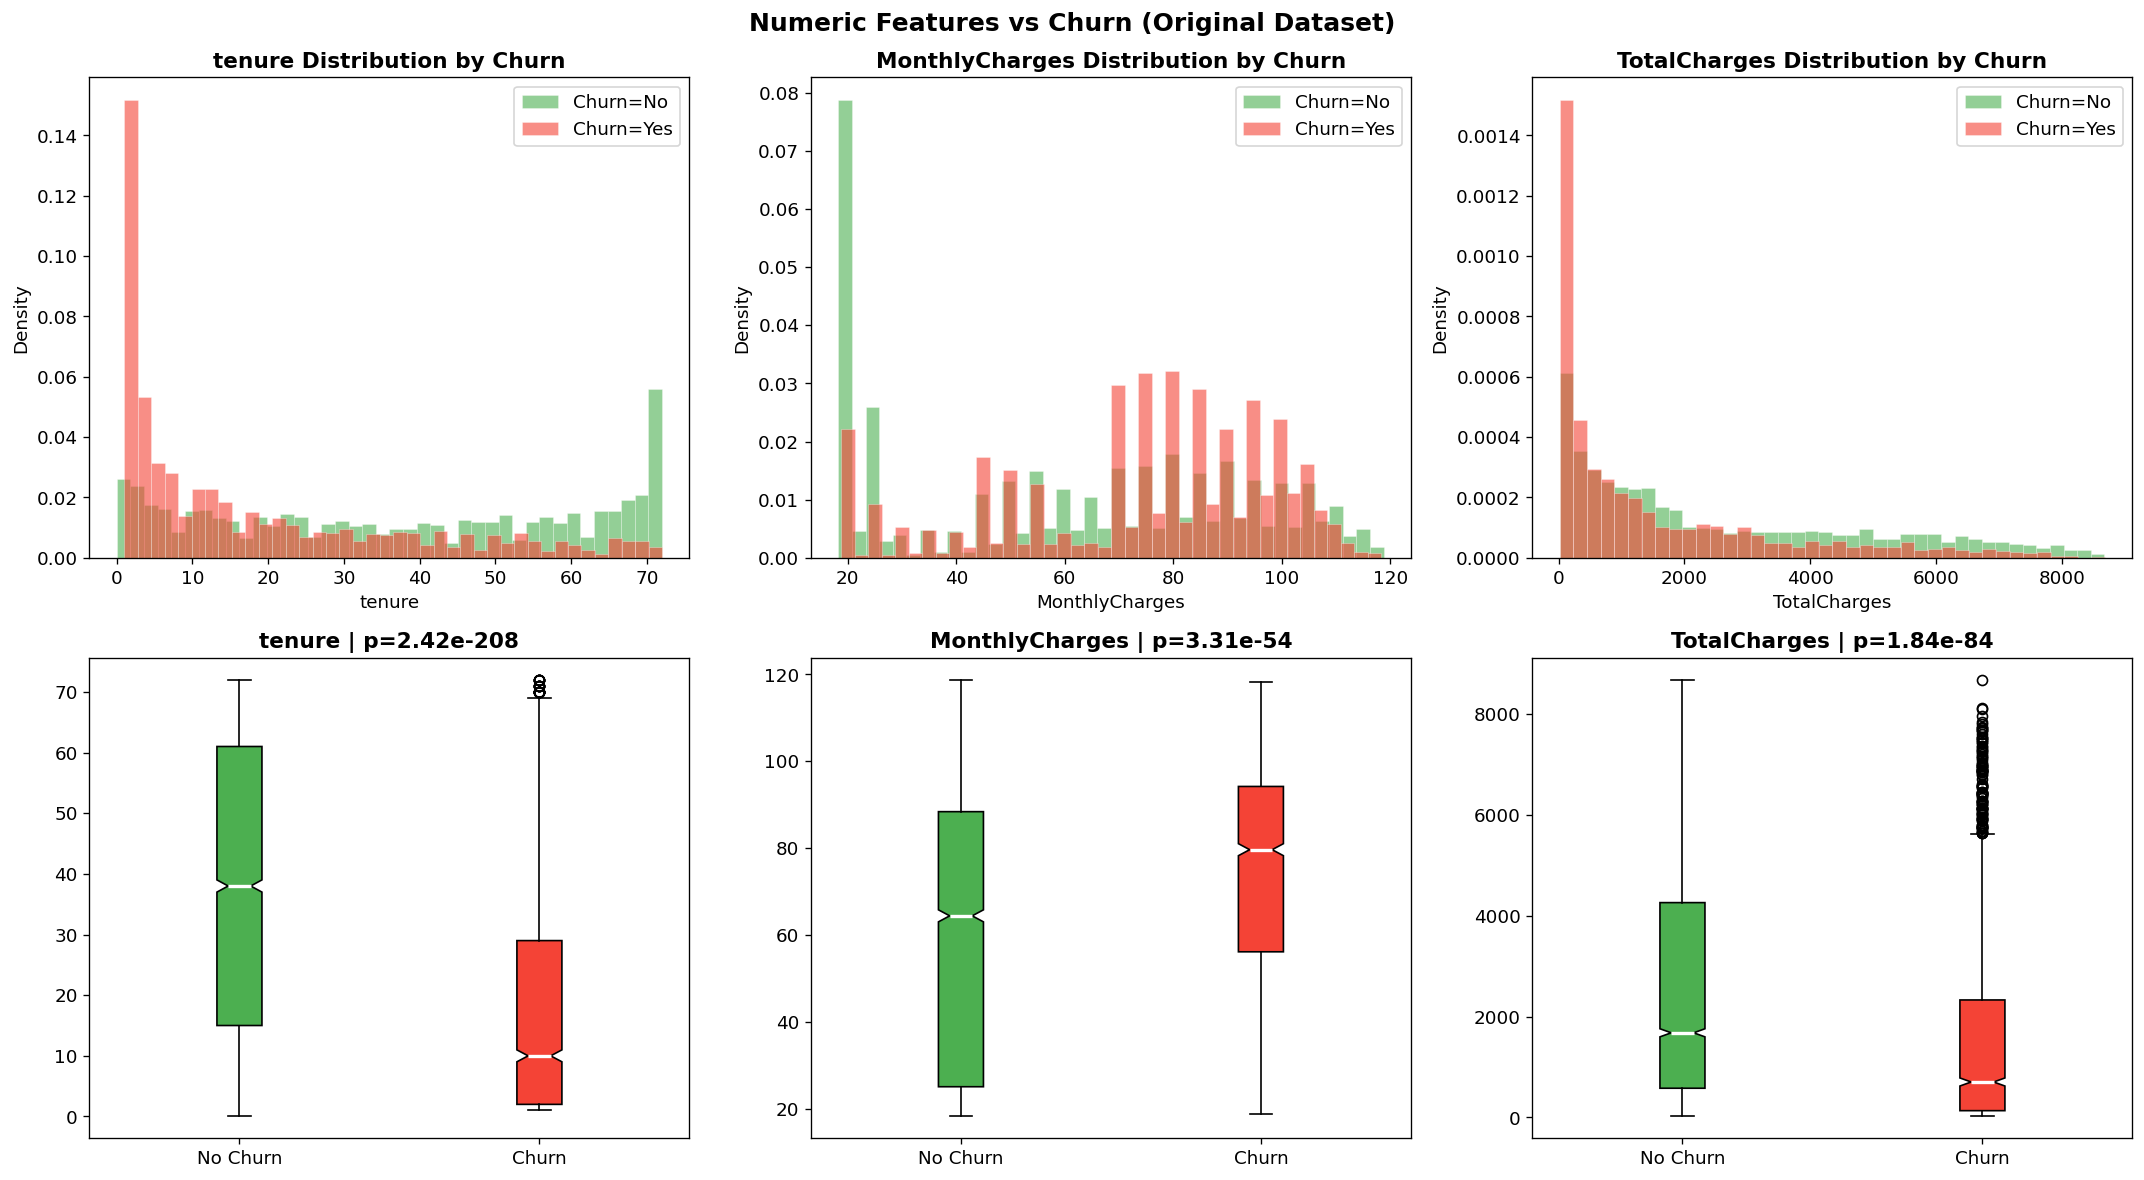

Numeric stats by churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.43       1679.52
Yes      10.0           79.65        703.55


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(NUM_COLS):
    # Distribution
    ax = axes[0, i]
    for label, grp in orig.groupby("Churn"):
        ax.hist(grp[col], bins=40, alpha=0.6, label=f"Churn={label}",
                color=PALETTE[label], density=True, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{col} Distribution by Churn")
    ax.set_xlabel(col); ax.set_ylabel("Density"); ax.legend()

    # Box plot
    ax = axes[1, i]
    data_n = orig[orig["Churn"]=="No"][col]
    data_y = orig[orig["Churn"]=="Yes"][col]
    bp = ax.boxplot([data_n, data_y], labels=["No Churn","Churn"],
                    patch_artist=True, notch=True,
                    medianprops={"color":"white","linewidth":2})
    bp["boxes"][0].set_facecolor("#4CAF50")
    bp["boxes"][1].set_facecolor("#F44336")
    stat, pval = stats.mannwhitneyu(data_n, data_y)
    ax.set_title(f"{col} | p={pval:.2e}")

plt.suptitle("Numeric Features vs Churn (Original Dataset)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_numeric_vs_churn.png", bbox_inches="tight", dpi=120)
plt.show()

print("Numeric stats by churn:")
print(orig.groupby("Churn")[NUM_COLS].median().round(2))


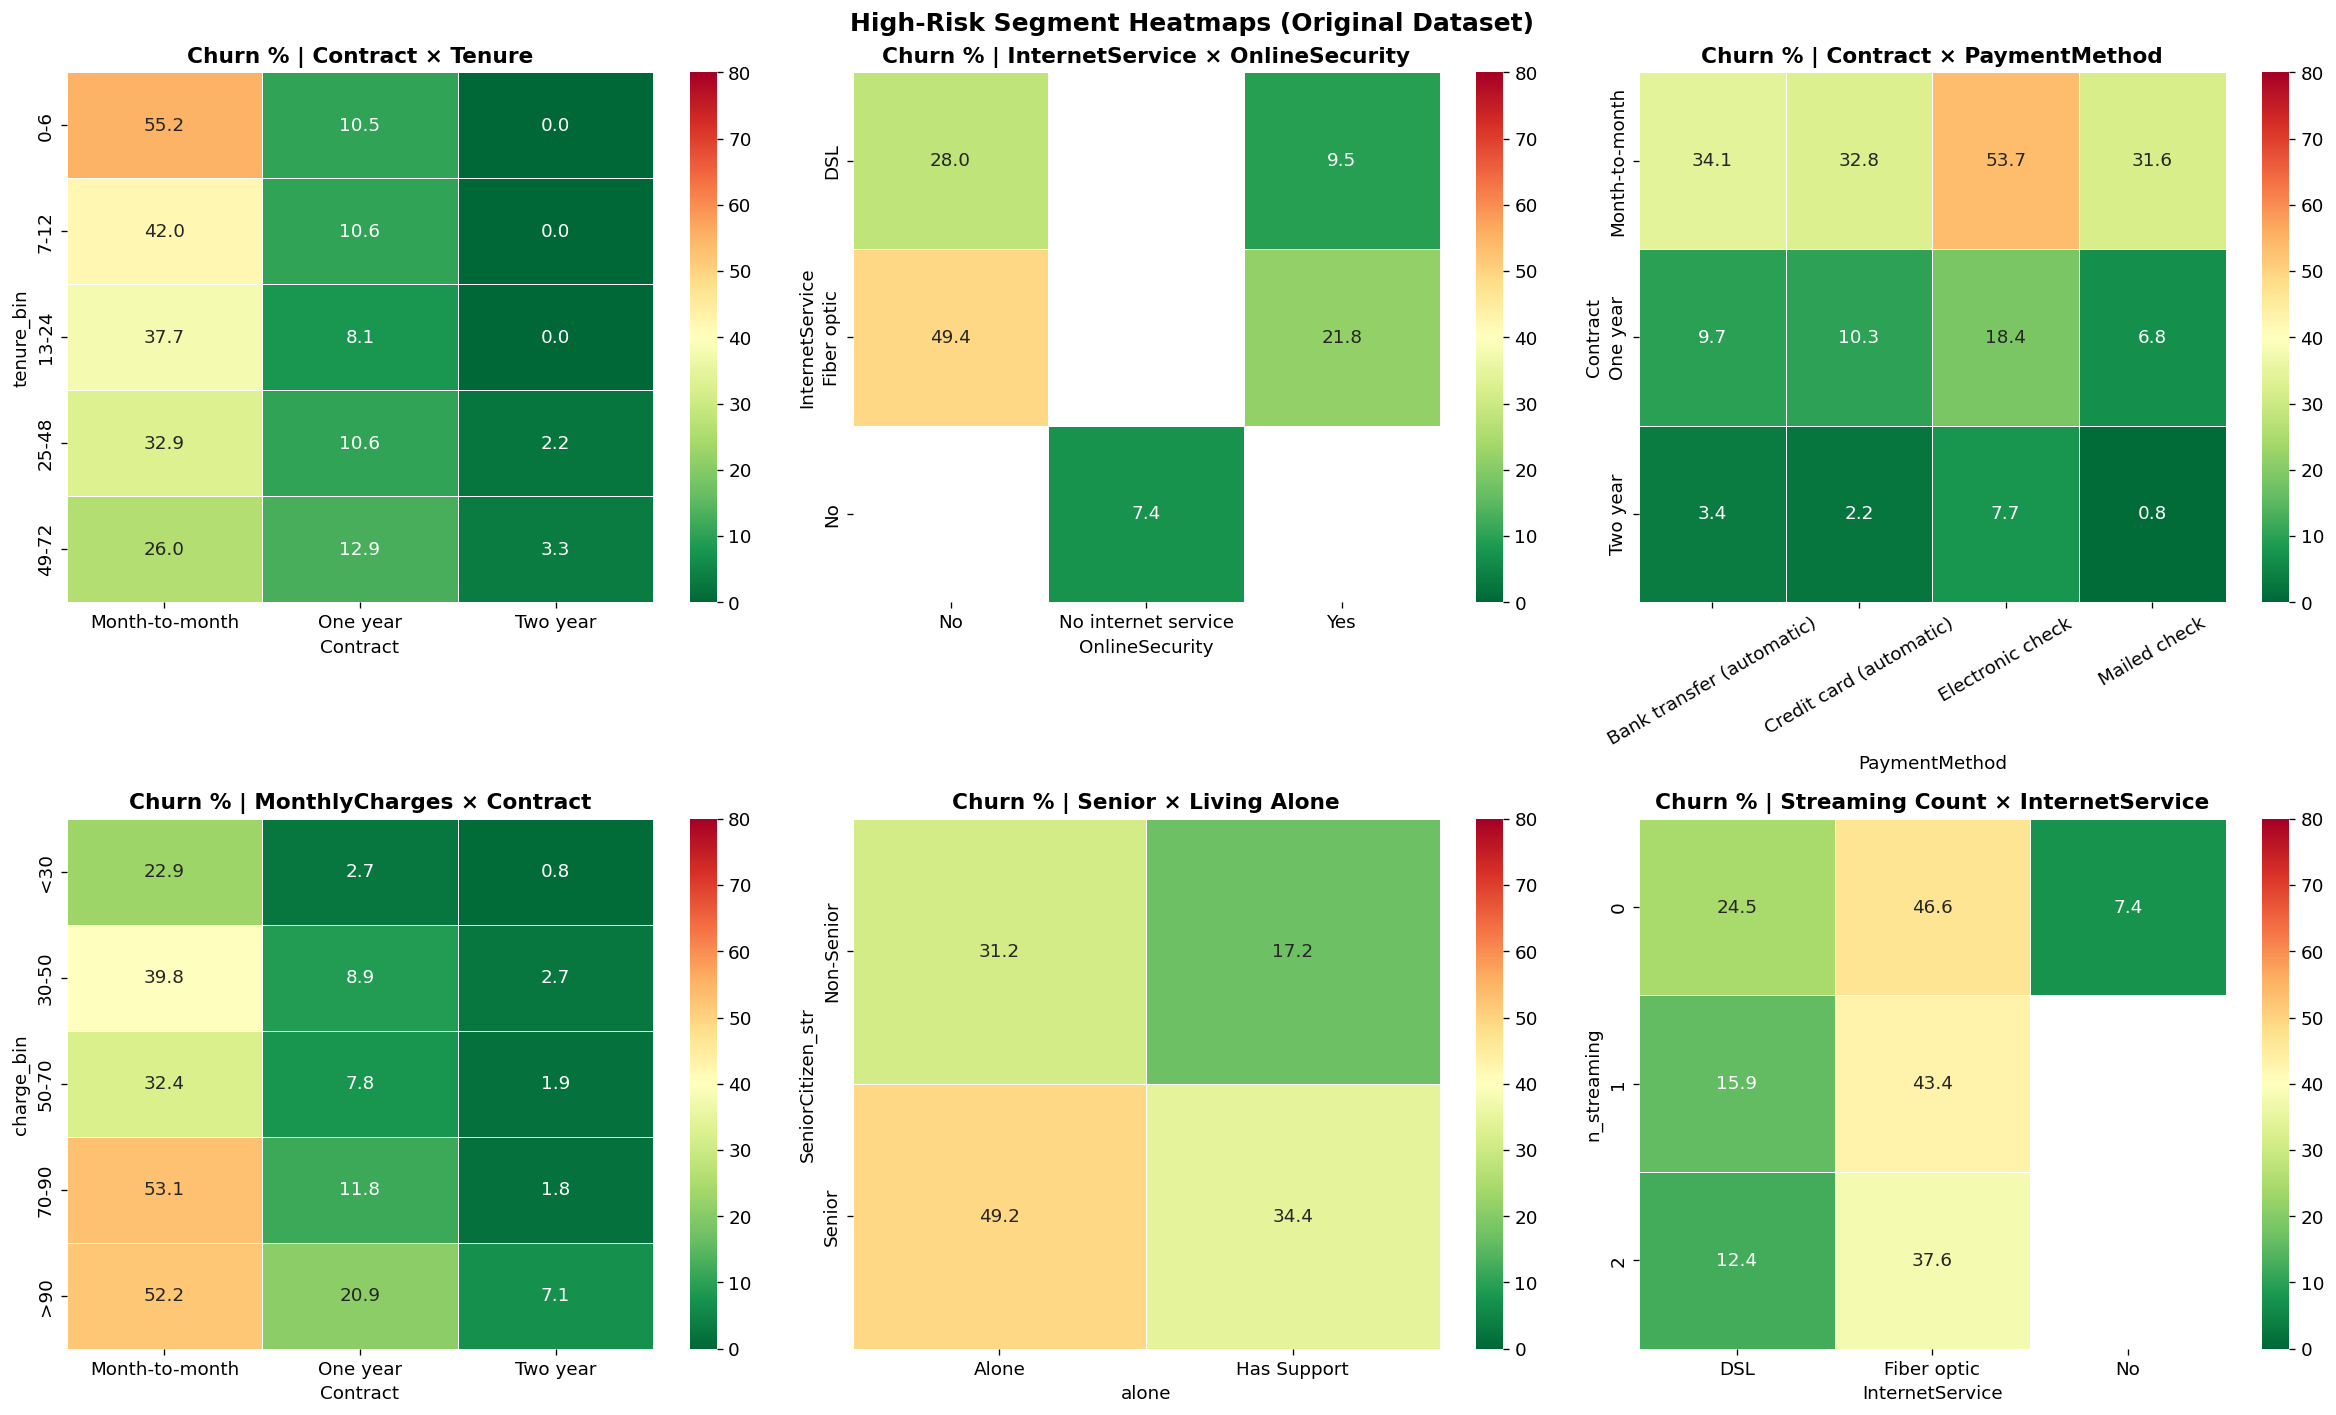

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Contract × tenure buckets
ax = axes[0, 0]
orig["tenure_bin"] = pd.cut(orig["tenure"],
                             bins=[0,6,12,24,48,72],
                             labels=["0-6","7-12","13-24","25-48","49-72"])
pivot = orig.pivot_table(values="Churn_bin", index="tenure_bin",
                          columns="Contract", aggfunc="mean") * 100
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            vmin=0, vmax=80, ax=ax, linewidths=0.5)
ax.set_title("Churn % | Contract × Tenure")

# 2. InternetService × OnlineSecurity
ax = axes[0, 1]
pivot2 = orig.pivot_table(values="Churn_bin",
                           index="InternetService", columns="OnlineSecurity",
                           aggfunc="mean") * 100
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="RdYlGn_r",
            vmin=0, vmax=80, ax=ax, linewidths=0.5)
ax.set_title("Churn % | InternetService × OnlineSecurity")

# 3. Contract × PaymentMethod
ax = axes[0, 2]
pivot3 = orig.pivot_table(values="Churn_bin",
                           index="Contract", columns="PaymentMethod",
                           aggfunc="mean") * 100
sns.heatmap(pivot3, annot=True, fmt=".1f", cmap="RdYlGn_r",
            vmin=0, vmax=80, ax=ax, linewidths=0.5)
ax.set_title("Churn % | Contract × PaymentMethod")
ax.tick_params(axis="x", rotation=30)

# 4. MonthlyCharges buckets × Contract
ax = axes[1, 0]
orig["charge_bin"] = pd.cut(orig["MonthlyCharges"],
                              bins=[0,30,50,70,90,120],
                              labels=["<30","30-50","50-70","70-90",">90"])
pivot4 = orig.pivot_table(values="Churn_bin",
                           index="charge_bin", columns="Contract",
                           aggfunc="mean") * 100
sns.heatmap(pivot4, annot=True, fmt=".1f", cmap="RdYlGn_r",
            vmin=0, vmax=80, ax=ax, linewidths=0.5)
ax.set_title("Churn % | MonthlyCharges × Contract")

# 5. Senior × Partner × Dependents
ax = axes[1, 1]
orig["SeniorCitizen_str"] = orig["SeniorCitizen"].map({0:"Non-Senior",1:"Senior"})
orig["alone"] = ((orig["Partner"]=="No") & (orig["Dependents"]=="No")).map({True:"Alone",False:"Has Support"})
pivot5 = orig.pivot_table(values="Churn_bin",
                           index="SeniorCitizen_str", columns="alone",
                           aggfunc="mean") * 100
sns.heatmap(pivot5, annot=True, fmt=".1f", cmap="RdYlGn_r",
            vmin=0, vmax=80, ax=ax, linewidths=0.5)
ax.set_title("Churn % | Senior × Living Alone")

# 6. StreamingTV + StreamingMovies × InternetService
ax = axes[1, 2]
orig["n_streaming"] = ((orig["StreamingTV"]=="Yes").astype(int) +
                        (orig["StreamingMovies"]=="Yes").astype(int))
pivot6 = orig.pivot_table(values="Churn_bin",
                           index="n_streaming", columns="InternetService",
                           aggfunc="mean") * 100
sns.heatmap(pivot6, annot=True, fmt=".1f", cmap="RdYlGn_r",
            vmin=0, vmax=80, ax=ax, linewidths=0.5)
ax.set_title("Churn % | Streaming Count × InternetService")

plt.suptitle("High-Risk Segment Heatmaps (Original Dataset)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_segment_heatmaps.png", bbox_inches="tight", dpi=120)
plt.show()


In [5]:
# Find the most extreme churn rate segments (2-way combos)
combos = [
    ("Contract", "InternetService"),
    ("Contract", "PaymentMethod"),
    ("Contract", "OnlineSecurity"),
    ("Contract", "TechSupport"),
    ("InternetService", "OnlineSecurity"),
    ("InternetService", "TechSupport"),
    ("tenure_bin", "Contract"),
    ("SeniorCitizen_str", "Contract"),
    ("alone", "Contract"),
    ("PaperlessBilling", "PaymentMethod"),
]

print("=" * 65)
print("TOP HIGH-RISK SEGMENTS (churn rate > 50%)")
print("=" * 65)
all_segments = []
for c1, c2 in combos:
    grp = orig.groupby([c1,c2])["Churn_bin"].agg(["mean","count"])
    grp.columns = ["churn_rate","count"]
    grp["churn_rate"] *= 100
    grp = grp[grp["count"] >= 20].sort_values("churn_rate", ascending=False)
    for idx, row in grp.iterrows():
        all_segments.append({
            "segment": f"{c1}={idx[0]} & {c2}={idx[1]}",
            "churn_rate": row["churn_rate"],
            "count": int(row["count"])
        })

seg_df = pd.DataFrame(all_segments).drop_duplicates("segment")
seg_df = seg_df.sort_values("churn_rate", ascending=False).head(20)

for _, r in seg_df.iterrows():
    bar = "█" * int(r["churn_rate"] / 3)
    print(f"  {r['churn_rate']:5.1f}% {bar}  ({r['count']:4d} customers)  {r['segment']}")


TOP HIGH-RISK SEGMENTS (churn rate > 50%)
   55.2% ██████████████████  (1413 customers)  tenure_bin=0-6 & Contract=Month-to-month
   54.6% ██████████████████  ( 807 customers)  SeniorCitizen_str=Senior & Contract=Month-to-month
   54.6% ██████████████████  (2128 customers)  Contract=Month-to-month & InternetService=Fiber optic
   53.7% █████████████████  (1850 customers)  Contract=Month-to-month & PaymentMethod=Electronic check
   51.0% █████████████████  (2631 customers)  Contract=Month-to-month & OnlineSecurity=No
   50.4% ████████████████  (2680 customers)  Contract=Month-to-month & TechSupport=No
   49.8% ████████████████  (1742 customers)  PaperlessBilling=Yes & PaymentMethod=Electronic check
   49.4% ████████████████  (2230 customers)  InternetService=Fiber optic & TechSupport=No
   49.4% ████████████████  (2257 customers)  InternetService=Fiber optic & OnlineSecurity=No
   45.8% ███████████████  (2288 customers)  alone=Alone & Contract=Month-to-month
   42.0% █████████████  ( 58

In [6]:
print("=" * 65)
print("DISTRIBUTION COMPARISON: Original vs Playground Train")
print("=" * 65)
print(f"\n{'Feature':25s} {'Orig Churn%':>12s} {'Train Churn%':>12s} {'Delta':>8s}")
print("-" * 65)

for col in CAT_COLS:
    orig_rate  = orig.groupby(col)["Churn_bin"].mean() * 100
    train_rate = train.groupby(col)["Churn_bin"].mean() * 100
    
    # Align on common categories
    common = orig_rate.index.intersection(train_rate.index)
    for cat in common:
        delta = train_rate[cat] - orig_rate[cat]
        flag  = " ◀ SHIFTED" if abs(delta) > 5 else ""
        print(f"  {col}.{cat:18s} {orig_rate[cat]:>10.1f}% {train_rate[cat]:>10.1f}% {delta:>+7.1f}pp{flag}")
    print()

# Numeric comparison
print("\nNumeric median comparison:")
print(f"{'Feature':20s} {'Orig median':>12s} {'Train median':>13s} {'Delta%':>8s}")
print("-" * 55)
for col in NUM_COLS:
    om = orig[col].median()
    tm = train[col].median()
    print(f"  {col:18s} {om:>12.2f} {tm:>12.2f} {(tm-om)/om*100:>+7.1f}%")


DISTRIBUTION COMPARISON: Original vs Playground Train

Feature                    Orig Churn% Train Churn%    Delta
-----------------------------------------------------------------
  gender.Female                   26.9%       22.8%    -4.1pp
  gender.Male                     26.2%       22.2%    -3.9pp

  Partner.No                       33.0%       32.5%    -0.5pp
  Partner.Yes                      19.7%       13.4%    -6.3pp ◀ SHIFTED

  Dependents.No                       31.3%       29.1%    -2.1pp
  Dependents.Yes                      15.5%        7.3%    -8.2pp ◀ SHIFTED

  PhoneService.No                       24.9%       16.8%    -8.1pp ◀ SHIFTED
  PhoneService.Yes                      26.7%       22.9%    -3.8pp

  MultipleLines.No                       25.0%       18.2%    -6.8pp ◀ SHIFTED
  MultipleLines.No phone service         24.9%       16.8%    -8.1pp ◀ SHIFTED
  MultipleLines.Yes                      28.6%       27.7%    -0.9pp

  InternetService.DSL                 

  PaperlessBilling.No                       16.3%        7.5%    -8.9pp ◀ SHIFTED
  PaperlessBilling.Yes                      33.6%       31.9%    -1.6pp



  PaymentMethod.Bank transfer (automatic)       16.7%        7.7%    -9.0pp ◀ SHIFTED
  PaymentMethod.Credit card (automatic)       15.2%        6.9%    -8.3pp ◀ SHIFTED
  PaymentMethod.Electronic check         45.3%       48.9%    +3.6pp
  PaymentMethod.Mailed check             19.1%        8.0%   -11.1pp ◀ SHIFTED


Numeric median comparison:
Feature               Orig median  Train median   Delta%
-------------------------------------------------------
  tenure                    29.00        35.00   +20.7%
  MonthlyCharges            70.35        74.10    +5.3%
  TotalCharges            1397.47      1433.65    +2.6%


ID COLUMN ANALYSIS (Playground)

ID range : 0 → 594,193
ID span  : 594,193
Rows     : 594,194


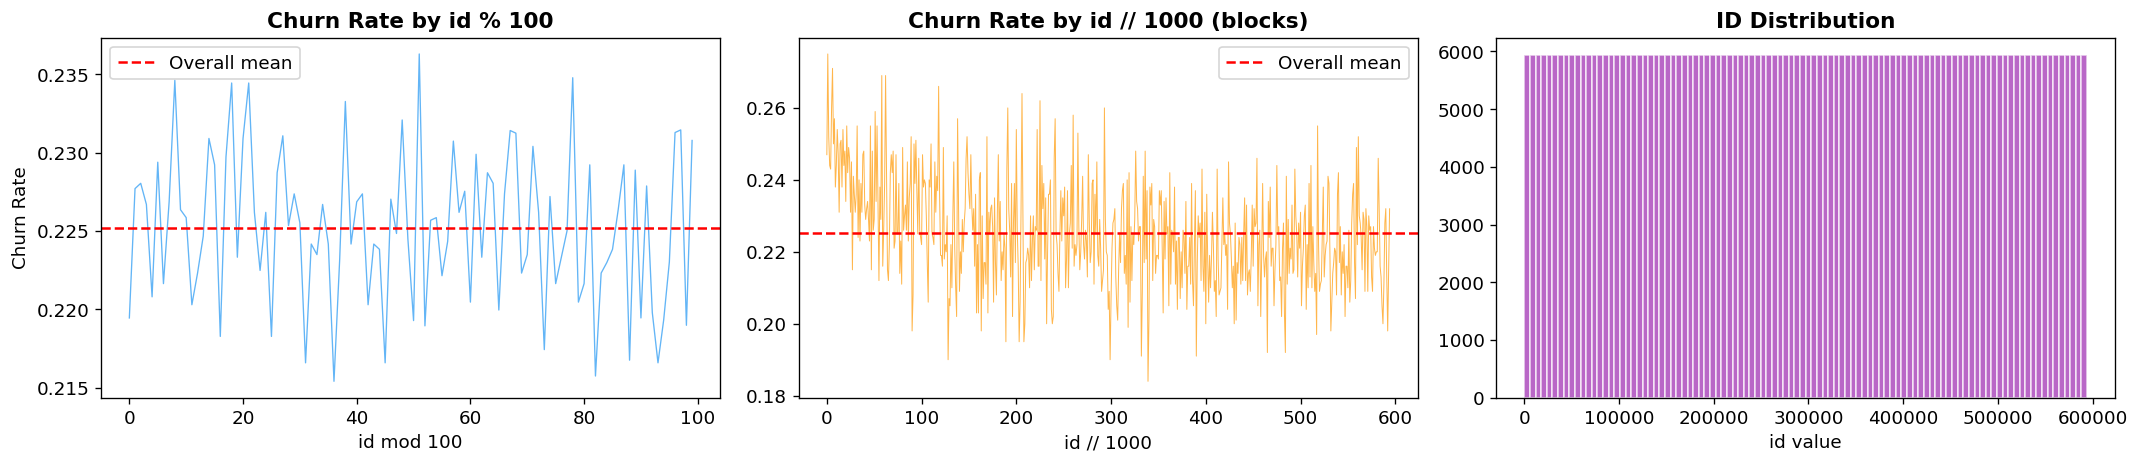


Spearman correlation (id vs Churn): r=-0.0130  p=0.0000
id has SIGNIFICANT predictive power


In [7]:
print("=" * 65)
print("ID COLUMN ANALYSIS (Playground)")
print("=" * 65)
print(f"\nID range : {train.id.min():,} → {train.id.max():,}")
print(f"ID span  : {train.id.max() - train.id.min():,}")
print(f"Rows     : {len(train):,}")

# Check if id has predictive power
train["id_mod_100"]  = train["id"] % 100
train["id_mod_1000"] = train["id"] % 1000
train["id_div_1000"] = train["id"] // 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# id % 100 vs churn
churn_by_mod = train.groupby("id_mod_100")["Churn_bin"].mean()
axes[0].plot(churn_by_mod.index, churn_by_mod.values, alpha=0.7, linewidth=0.8, color="#2196F3")
axes[0].axhline(train.Churn_bin.mean(), color="red", linestyle="--", label="Overall mean")
axes[0].set_title("Churn Rate by id % 100")
axes[0].set_xlabel("id mod 100"); axes[0].set_ylabel("Churn Rate"); axes[0].legend()

# id // 1000 vs churn (batch blocks)
churn_by_block = train.groupby("id_div_1000")["Churn_bin"].mean()
axes[1].plot(churn_by_block.index, churn_by_block.values, alpha=0.7, linewidth=0.6, color="#FF9800")
axes[1].axhline(train.Churn_bin.mean(), color="red", linestyle="--", label="Overall mean")
axes[1].set_title("Churn Rate by id // 1000 (blocks)")
axes[1].set_xlabel("id // 1000"); axes[1].legend()

# id distribution
axes[2].hist(train["id"], bins=100, color="#9C27B0", alpha=0.7, edgecolor="white")
axes[2].set_title("ID Distribution")
axes[2].set_xlabel("id value")

plt.tight_layout()
plt.savefig("eda_id_analysis.png", bbox_inches="tight", dpi=120)
plt.show()

# Correlation of id with target
from scipy.stats import spearmanr
r, p = spearmanr(train["id"], train["Churn_bin"])
print(f"\nSpearman correlation (id vs Churn): r={r:.4f}  p={p:.4f}")
print(f"id has {'SIGNIFICANT' if p < 0.05 else 'NO significant'} predictive power")


In [8]:
print("=" * 65)
print("PROPOSED FEATURE ENGINEERING FROM EDA")
print("=" * 65)

# Demonstrate churn rates for proposed features
orig["is_month_to_month"]     = (orig["Contract"] == "Month-to-month").astype(int)
orig["is_fiber_no_security"]  = ((orig["InternetService"] == "Fiber optic") &
                                  (orig["OnlineSecurity"] == "No")).astype(int)
orig["is_echeck_mtm"]         = ((orig["PaymentMethod"] == "Electronic check") &
                                  (orig["Contract"] == "Month-to-month")).astype(int)
orig["is_senior_alone_fiber"] = ((orig["SeniorCitizen"] == 1) &
                                  (orig["alone"] == "Alone") &
                                  (orig["InternetService"] == "Fiber optic")).astype(int)
orig["is_new_mtm"]            = ((orig["tenure"] <= 12) &
                                  (orig["Contract"] == "Month-to-month")).astype(int)
orig["is_high_charge_no_lock"]= ((orig["MonthlyCharges"] > 70) &
                                  (orig["Contract"] == "Month-to-month")).astype(int)
orig["n_security_services"]   = (
    (orig["OnlineSecurity"]=="Yes").astype(int) +
    (orig["OnlineBackup"]=="Yes").astype(int) +
    (orig["DeviceProtection"]=="Yes").astype(int) +
    (orig["TechSupport"]=="Yes").astype(int)
)
orig["is_fiber_no_support"]   = ((orig["InternetService"] == "Fiber optic") &
                                  (orig["n_security_services"] == 0)).astype(int)

proposed = [
    ("is_month_to_month",     "Contract == Month-to-month"),
    ("is_fiber_no_security",  "Fiber optic AND no OnlineSecurity"),
    ("is_echeck_mtm",         "Electronic check AND Month-to-month"),
    ("is_new_mtm",            "Tenure ≤ 12mo AND Month-to-month"),
    ("is_high_charge_no_lock","MonthlyCharges > $70 AND Month-to-month"),
    ("is_senior_alone_fiber", "Senior AND Alone AND Fiber optic"),
    ("is_fiber_no_support",   "Fiber optic AND zero security services"),
]

overall = orig["Churn_bin"].mean() * 100
print(f"  Overall churn rate: {overall:.1f}%\n")
print(f"  {'Feature':30s} {'N':>6s} {'Churn%':>8s} {'Lift':>8s}")
print("  " + "-" * 58)
for feat, desc in proposed:
    sub = orig[orig[feat]==1]
    if len(sub) == 0: continue
    rate = sub["Churn_bin"].mean() * 100
    lift = rate / overall
    print(f"  {desc:40s} {len(sub):>6,} {rate:>7.1f}% {lift:>7.2f}x")

# Number of security services vs churn
print("\n  n_security_services vs churn rate:")
for n, grp in orig.groupby("n_security_services"):
    r = grp["Churn_bin"].mean()*100
    bar = "█" * int(r/3)
    print(f"    {n} services : {r:.1f}%  {bar}  ({len(grp):,} customers)")


PROPOSED FEATURE ENGINEERING FROM EDA
  Overall churn rate: 26.5%

  Feature                             N   Churn%     Lift
  ----------------------------------------------------------
  Contract == Month-to-month                3,875    42.7%    1.61x
  Fiber optic AND no OnlineSecurity         2,257    49.4%    1.86x
  Electronic check AND Month-to-month       1,850    53.7%    2.02x
  Tenure ≤ 12mo AND Month-to-month          1,994    51.4%    1.94x
  MonthlyCharges > $70 AND Month-to-month   2,097    52.7%    1.99x
  Senior AND Alone AND Fiber optic            403    55.1%    2.08x
  Fiber optic AND zero security services      848    63.6%    2.40x

  n_security_services vs churn rate:
    0 services : 29.8%  █████████  (2,793 customers)
    1 services : 38.9%  ████████████  (1,467 customers)
    2 services : 23.8%  ███████  (1,372 customers)
    3 services : 12.4%  ████  (941 customers)
    4 services : 5.3%  █  (470 customers)


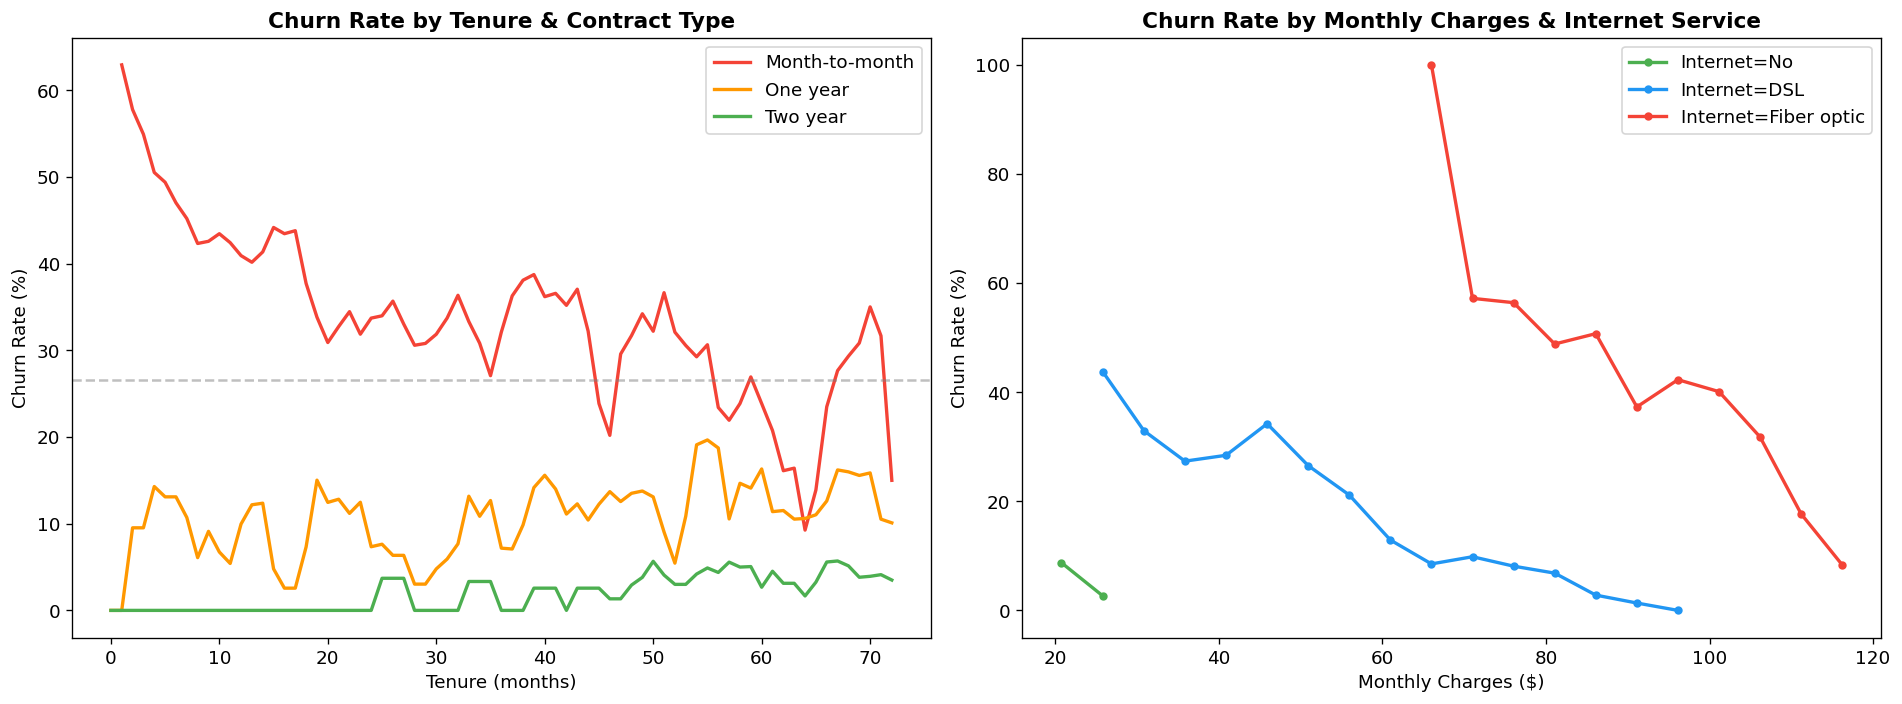

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Churn rate by tenure for each contract type
ax = axes[0]
for contract, color in zip(["Month-to-month","One year","Two year"],
                             ["#F44336","#FF9800","#4CAF50"]):
    sub = orig[orig["Contract"]==contract]
    rates = sub.groupby("tenure")["Churn_bin"].mean() * 100
    ax.plot(rates.index, rates.rolling(3, min_periods=1).mean(),
            label=contract, color=color, linewidth=2)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Tenure & Contract Type")
ax.legend()
ax.axhline(overall, color="gray", linestyle="--", alpha=0.5, label="Overall")

# Churn rate by MonthlyCharges for each InternetService
ax = axes[1]
orig["charge_band"] = pd.cut(orig["MonthlyCharges"], bins=20)
for svc, color in zip(["No","DSL","Fiber optic"],
                        ["#4CAF50","#2196F3","#F44336"]):
    sub = orig[orig["InternetService"]==svc]
    rates = sub.groupby("charge_band", observed=False)["Churn_bin"].mean() * 100
    midpoints = [float(str(i).strip("(]").split(",")[0]) +
                 (float(str(i).strip("(]").split(",")[1]) -
                  float(str(i).strip("(]").split(",")[0]))/2
                 for i in rates.index]
    ax.plot(midpoints, rates.values, label=f"Internet={svc}",
            color=color, linewidth=2, marker="o", markersize=4)
ax.set_xlabel("Monthly Charges ($)")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Monthly Charges & Internet Service")
ax.legend()

plt.tight_layout()
plt.savefig("eda_survival_curves.png", bbox_inches="tight", dpi=120)
plt.show()


In [10]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          EDA SUMMARY & ACTION PLAN                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  TOP CHURN DRIVERS (by discriminative power):               ║
║  1. Contract type     — Month-to-month >> One year >> Two yr║
║  2. Tenure            — Sharp drop after 12 months          ║
║  3. Internet service  — Fiber optic has 2x churn vs DSL     ║
║  4. Security services — 0 services = highest risk           ║
║  5. Payment method    — Electronic check = highest churn     ║
║  6. Senior + alone    — Vulnerable, especially on fiber      ║
║                                                              ║
║  HIGH-VALUE INTERACTION FEATURES TO BUILD:                  ║
║  A. is_fiber_no_support  (Fiber + 0 security services)      ║
║  B. is_new_mtm           (tenure ≤ 12 + Month-to-month)     ║
║  C. is_echeck_mtm        (ElecCheck + Month-to-month)       ║
║  D. is_high_charge_mtm   (charges>$70 + Month-to-month)     ║
║  E. n_security_services  (count of 4 security services)     ║
║  F. is_senior_alone      (Senior + no partner/dependents)   ║
║                                                              ║
║  DISTRIBUTION SHIFTS (Orig vs Playground):                  ║
║  • Playground churn rate 22.5% vs original 26.5%            ║
║  • Check cell 6 output for per-feature shifts               ║
║                                                              ║
║  ID COLUMN:                                                  ║
║  • Check cell 7 output — id may/may not encode signal        ║
║                                                              ║
║  NEXT STEPS:                                                 ║
║  1. Add original 7K rows as training data                   ║
║  2. Build 6 interaction features above (A-F)                ║
║  3. Replace generic FE with domain-driven FE                ║
║  4. Re-run nb10 architecture with new features              ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║          EDA SUMMARY & ACTION PLAN                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  TOP CHURN DRIVERS (by discriminative power):               ║
║  1. Contract type     — Month-to-month >> One year >> Two yr║
║  2. Tenure            — Sharp drop after 12 months          ║
║  3. Internet service  — Fiber optic has 2x churn vs DSL     ║
║  4. Security services — 0 services = highest risk           ║
║  5. Payment method    — Electronic check = highest churn     ║
║  6. Senior + alone    — Vulnerable, especially on fiber      ║
║                                                              ║
║  HIGH-VALUE INTERACTION FEATURES TO BUILD:                  ║
║  A. is_fiber_no_support  (Fiber + 0 security services)      ║
║  B. is_new_mtm           (tenure ≤ 12 + Month-to-month)     ║
║  C. is_echeck_mtm        (ElecC